In [1]:
import sys
sys.path.insert(0, '/Users/antonk/n/nextsim-tools/python')
from pynextsim.irregular_grid_interpolator import IrregularGridInterpolator

In [2]:
import os
from datetime import datetime, timedelta
import glob
import gc

from tqdm.notebook import tqdm, trange
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.ndimage import minimum_filter, median_filter, gaussian_filter
from scipy.interpolate import RegularGridInterpolator

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from matplotlib.tri import Triangulation
from lmsiage.utils import IrregularGridInterpolator
from scipy.interpolate import griddata
from cartopy import crs as ccrs

from lmsiage.mesh_file import MeshFile

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [3]:
class Dist2Coast:
    def __init__(self, path='/Users/antonk/Data/dist2coast_4deg.npy', srs_dst=None):
        self.dist2coast = np.load(path)
        if srs_dst is None:
            srs_dst = ccrs.NorthPolarStereo(central_longitude=-45, true_scale_latitude=60)
        self.srs_dst = srs_dst

    def __getitem__(self, key):
        x, y = key[0].flatten(), key[1].flatten()
        dist = np.zeros_like(x) + np.nan
        srs_wgs = ccrs.PlateCarree()
        lon, lat, _ = srs_wgs.transform_points(self.srs_dst, x, y).T
        col = np.round((180 + lon)*25).astype(int)
        row = np.round((90 - lat)*25).astype(int)
        gpi = (col > 0) * (col < self.dist2coast.shape[1]) * (row > 0) * (row < self.dist2coast.shape[0])
        dist[gpi] = self.dist2coast[row[gpi], col[gpi]]
        return dist.reshape(key[0].shape)


In [4]:
all_experiments = {
    'da2':dict(
        # No DA, erase coast SIC
        uncert_factor = 2.0,
        uncert_offset = 1.0,
        r2_power = 2,
        min_myi_pred = 15,  # minim
        min_dist = 50,        
        erase_coast_sic = True,
    ),
    'da2a': dict(
        # erase coast SIC, weak DA
        uncert_factor = 2,
        uncert_offset = 0.5,
        r2_power = 2,
        min_myi_pred = 5,
        min_dist = 50,
        erase_coast_sic = True,
    ),
    'da2b': dict(
        uncert_factor = 1,
        uncert_offset = 0.5,
        r2_power = 2,
        min_myi_pred = 5,
        min_dist = 50,
        erase_coast_sic = True,
    ),
    'da2c': dict(
        uncert_factor = 0.5,
        uncert_offset = 0.5,
        r2_power = 2,
        min_myi_pred = 5,
        min_dist = 50,
        erase_coast_sic = True,
    ),
    'da2d': dict(
        uncert_factor = 1,
        uncert_offset = 0.25,
        r2_power = 2,
        min_myi_pred = 5,
        min_dist = 50,
        erase_coast_sic = True,
    ),
    'da2e': dict(
        uncert_factor = 0.5,
        uncert_offset = 0.25,
        r2_power = 2,
        min_myi_pred = 5,
        min_dist = 50,
        erase_coast_sic = True,
    ),
    'da2f':dict(
        # No DA, erase coast SIC
        uncert_factor = 2.0,
        uncert_offset = 1.0,
        r2_power = 2,
        min_myi_pred = 15,  # minim
        min_dist = 50,        
        erase_coast_sic = True,
    ),
    'da2g': dict(
        # erase coast SIC, weak DA
        uncert_factor = 2,
        uncert_offset = 0.5,
        r2_power = 2,
        min_myi_pred = 5,
        min_dist = 50,
        erase_coast_sic = True,
    ),
}

exp_names = ['da2g']
experiments = {exp_name: all_experiments[exp_name] for exp_name in exp_names}

In [5]:
# read the data
with xr.open_dataset('SAGE_RRDP/s_rrdp_v01_fv02/20200103_N_v01_fv02.nc') as ds:
    xc = ds['xc'].values
    yc = ds['yc'].values
    # Create feature names based on the data variables
    feature_names = []
    for v in sorted(ds.variables):
        if v.startswith('ASCAT_') or (v.startswith('AMSR2_') and v.endswith('_M')):
            feature_names.append(v)    
xcg, ycg = np.meshgrid(xc, yc)

with np.load('../sea_ice_age/mesh_arctic_ease_25km_max7.npz') as npz:
    landmask = npz['landmask']
    mask = npz['mask']
    x = npz['xc'] * 1000
    y = npz['yc'][::-1] * 1000
xg, yg = np.meshgrid(x, y)
srs_dst = ccrs.LambertAzimuthalEqualArea(central_longitude=0, central_latitude=90)
d2c = Dist2Coast(srs_dst=srs_dst)
dist = d2c[xg, yg]


mask_interpolator0 = RegularGridInterpolator((y, x), mask, bounds_error=False, fill_value=0.0)
mask_rrdp = mask_interpolator0((ycg.flatten(), xcg.flatten())).reshape(xcg.shape)
landmask_interpolator0 = RegularGridInterpolator((y, x), landmask, bounds_error=False, fill_value=0.0)
landmask_rrdp = landmask_interpolator0((ycg.flatten(), xcg.flatten())).reshape(xcg.shape)
dist_interpolator0 = RegularGridInterpolator((y, x), dist, bounds_error=False, fill_value=np.nan)

# for mesh:
mask_interpolator = RegularGridInterpolator((y, x), minimum_filter(mask, 5), bounds_error=False, fill_value=0.0)


In [6]:
MAX_LEN_FRACTIONS = 6
force = True

sia_dir = 'NERSC_arctic25km_sea_ice_age_DA'
mesh_dir = f'{sia_dir}/mesh'
mesh_files = sorted(glob.glob(f'{mesh_dir}/*/mesh_*.zip'))

In [85]:
for exp_name, experiment in experiments.items():
    uncert_factor = experiment['uncert_factor']
    uncert_offset = experiment['uncert_offset']
    r2_power = experiment['r2_power']
    min_myi_pred = experiment['min_myi_pred']
    min_dist = experiment['min_dist']
    da_grid_output_dir = f'./collocated_{exp_name}'
    erase_coast_sic = experiment['erase_coast_sic']

    age_dir = f'{sia_dir}/age_da_{exp_name}'
    age_files = sorted(glob.glob(f'{age_dir}/*/age_*.zip'))
    start_file = f'{age_dir}/2020/age_20200915.zip'

    not_myi_files = [f for f in age_files if '0915.zip' not in f]
    if len(not_myi_files) > 0 and not force:
        start_file = not_myi_files[-1]
    start_date = datetime.strptime(os.path.basename(start_file), 'age_%Y%m%d.zip')
    end_date = datetime.strptime(os.path.basename(mesh_files[-1]), 'mesh_%Y%m%d.zip')
    end_date = datetime(2020, 9, 27)
    duration = (end_date - start_date).days
    print(exp_name, start_date, end_date, duration, da_grid_output_dir)

    for i in trange(duration):
        src_file_date = start_date + timedelta(i)
        dst_file_date = start_date + timedelta(i + 1)
        
        # load previously propagated MYI
        src_age_path = src_file_date.strftime(f'{age_dir}/%Y/age_%Y%m%d.zip')
        src_age = MeshFile(src_age_path)
        src_names = src_age.read_names()
        # select only N most recent fractions, N = MAX_LEN_FRACTIONS
        myi_names = sorted([n for n in src_names if n.startswith('sic') and len(n) > 3], reverse=True)[:MAX_LEN_FRACTIONS][::-1]
        src_myi = src_age.load(myi_names)
        
        # load mesh
        dst_mesh_path = dst_file_date.strftime(f'{mesh_dir}/%Y/mesh_%Y%m%d.zip')
        dst_mesh = MeshFile(dst_mesh_path)
        src2dst, w, ar, sic, x, y, t = dst_mesh.load(['src2dst', 'weights', 'ar', 'sic', 'x', 'y', 't'], as_dict=False)
        ar[ar == 0] = 0.01

        # Erase coastal SIC
        erase_coast_myi = False
        if datetime(src_file_date.year, 8, 15) <= src_file_date <= datetime(src_file_date.year, 9, 16) and erase_coast_sic:
            xel = x[t].mean(axis=1)
            yel = y[t].mean(axis=1)
            dist_mesh = dist_interpolator0(np.c_[yel*1000, xel*1000])
            lat_mesh = np.hypot(xel - -600, yel - -200)
            lat_mesh = lat_mesh.max() - lat_mesh
            sic[(dist_mesh < 40) & (lat_mesh < 1000)] = 0.0
            #print(f'Erased coastal SIC for {src_file_date.strftime("%Y-%m-%d")}')
            erase_coast_myi = True

        # propagate all previous MYI
        dst_myi = {} # True destination MYI - advection and area correction
        dst_myi_a = {} # Advection only
        for name, c0 in src_myi.items():
            # advect
            c1 = np.zeros(src2dst[:,1].max()+1)
            np.add.at(c1, src2dst[:,1], c0[src2dst[:,0]] * w)

            if erase_coast_myi:
                c1[(dist_mesh < 40) & (lat_mesh < 1000)] = 0.0
            
            # clip advected by realistic values
            c1a = np.clip(c1, 0, 100)
            #c1a = np.where(c1a > sic, sic, c1a)
            dst_myi_a[name] = c1a

            # correct the advected for area change and observed SIC
            c1 /= ar
            c1 = np.clip(c1, 0, 100)
            c1 = np.where(c1 > sic, sic, c1)
            dst_myi[name] = c1
        
        # Data assimilation
        src_mesh_path = src_file_date.strftime(f'{mesh_dir}/%Y/mesh_%Y%m%d.zip')
        src_mesh = MeshFile(src_mesh_path)
        x0_mesh, y0_mesh, t0 = src_mesh.load(['x', 'y', 't'], as_dict=False)
        x1_mesh, y1_mesh, t1 = dst_mesh.load(['x', 'y', 't'], as_dict=False)
        snapshot_file = f'SAGE_RRDP/s_rrdp_v01_fv02/{dst_file_date.strftime("%Y%m%d")}_N_v01_fv02.nc'
        da_performed = False
        NIC_dom_icetype_in_file = False
        if not os.path.exists(snapshot_file):
            #print(f'Snapshot file not found: {snapshot_file}, skipping DA')
            pass
        elif (dst_file_date.month > 5 and (dst_file_date.month <= 9 and dst_file_date.day < 15)):
            #print(f'Summer month {dst_file_date}, skipping DA')
            pass
        else:
            with xr.open_dataset(snapshot_file) as ds:    
                data = []
                for v in sorted(feature_names):
                    if v in ds.variables:
                        data.append(ds[v][0,:,:].values)
                if 'NIC_dom_icetype' in ds.variables:
                    NIC_dom_icetype_in_file = True
            if len(data) < 13:
                print(f'Not enough features ({len(data)}) in snapshot file: {snapshot_file}, skipping DA')
            else:
                igi1_inv = IrregularGridInterpolator(xcg.flatten(), ycg.flatten(), x1_mesh[t1].mean(axis=1)*1000, y1_mesh[t1].mean(axis=1)*1000)
                data_mesh = []
                for i in range(len(data)):
                    data_mesh.append(igi1_inv.interp_field(data[i].flatten()))
                data_mesh = np.array(data_mesh)

                tri = Triangulation(x1_mesh, y1_mesh, t1)
                myi_name_DA = sorted(myi_names)[-1]  # assimilate only the most recent fraction

                # full forecast (including area correction and SIC correction)
                myi1 = dst_myi[myi_name_DA]
                # advection only
                myi1a = dst_myi_a[myi_name_DA]

                mask_min_myi = myi1a > min_myi_pred

                #plt.tripcolor(x1_mesh, y1_mesh, t1, mask_min_myi, vmin=0, vmax=1)
                #plt.show()

                myi_idx = np.nonzero(mask_min_myi)[0]
                #print(myi_idx.size)
                myi_idx = np.unique(tri.neighbors[myi_idx].flatten())
                #print(myi_idx.size)
                mask_min_myi[myi_idx] = True

                #plt.tripcolor(x1_mesh, y1_mesh, t1, mask_min_myi, vmin=0, vmax=1)
                #plt.show()

                xel = x1_mesh[t1].mean(axis=1)
                yel = y1_mesh[t1].mean(axis=1)
                dist_mesh = dist_interpolator0(np.c_[yel*1000, xel*1000])

                mask_dist = dist_mesh > min_dist

                #plt.tripcolor(x1_mesh, y1_mesh, t1, mask_dist, vmin=0, vmax=1)
                #plt.show()

                mask_mesh = mask_min_myi & mask_dist

                #plt.tripcolor(x1_mesh, y1_mesh, t1, mask_mesh, vmin=0, vmax=1)
                #plt.show()

                x = data_mesh[:, mask_mesh].T
                y = myi1a[mask_mesh]

                y_pred = []
                r2s = []
                mses = []
                for i in range(20):
                    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8)
                    regr = RandomForestRegressor(n_estimators=1, max_depth=20, min_samples_split=5, min_samples_leaf=1, n_jobs=-1, max_samples=0.3)
                    # Create pipeline with StandardScaler and a regressor
                    pipeline = Pipeline([
                        ('scaler', StandardScaler()),
                        ('regressor', regr)
                    ])
                    pipeline.fit(x_train, y_train)

                    y_test_pred = pipeline.predict(x_test)
                    r2 = r2_score(y_test, y_test_pred)
                    mse = mean_squared_error(y_test, y_test_pred)
                    r2s.append(r2)
                    mses.append(mse)
                    y_pred.append(pipeline.predict(x))

                y_pred = np.array(y_pred)
                r2s = np.array(r2s)
                myi1_pred_mean = (y_pred * r2s[None].T).sum(axis=0) / r2s.sum()
                myi1_pred_var = y_pred.std(axis=0) / myi1_pred_mean
                myi1_pred_var[myi1_pred_mean == 0] = 0

                #max_var = 1
                #plt.scatter(y[myi1_pred_var<max_var], myi1_pred_mean[myi1_pred_var<max_var], c=myi1_pred_var[myi1_pred_var<max_var], alpha=0.1, s=5, cmap='viridis', vmin=0, vmax=1)
                #plt.colorbar()
                #plt.show()

                #plt_myi1_pred = np.full(mask_mesh.shape, np.nan)
                #plt_myi1_pred[mask_mesh] = myi1_pred_mean
                #plt_myi1_pred_var = np.full(mask_mesh.shape, np.nan)
                #plt_myi1_pred_var[mask_mesh] = myi1_pred_var
                #plt.tripcolor(x1_mesh, y1_mesh, t1, plt_myi1_pred, vmin=0, vmax=100, cmap='viridis')
                #plt.show()

                #plt.tripcolor(x1_mesh, y1_mesh, t1, plt_myi1_pred_var, vmin=0, vmax=2, cmap='viridis')
                #plt.show()
                pred_uncert = np.clip(uncert_factor * myi1_pred_var + uncert_offset, 0, 1) ** (np.mean(r2s)**r2_power)
                pred_uncert[~np.isfinite(pred_uncert)] = 1.0

                #plt_pred_uncert = np.zeros(mask_mesh.shape)
                #plt_pred_uncert[mask_mesh] = pred_uncert
                #plt.tripcolor(x1_mesh, y1_mesh, t1, plt_pred_uncert, vmin=0, vmax=1, cmap='jet')
                #plt.colorbar()
                #plt.show()

                myi1_da = myi1.copy()
                myi1_da[mask_mesh] = myi1[mask_mesh] * pred_uncert + myi1_pred_mean * (1 - pred_uncert)

                #plt.tripcolor(x1_mesh, y1_mesh, t1, myi1_da, vmin=0, vmax=100, cmap='viridis')
                #plt.show()

                #plt.tripcolor(x1_mesh, y1_mesh, t1, myi1_da - myi1, vmin=-20, vmax=20, cmap='coolwarm')
                #plt.show()

                # compensate for negative bias in high concentration range
                #myi1_da[myi1_da > 85] = myi1_da[myi1_da > 85] * 1.0015

                myi1_da[myi1_da < 0] = 0.0
                dst_myi[myi_name_DA] = myi1_da
                
                # remove inconsistencies (replace values larger that younger fractions with the younger fraction values)
                #normalised_data = {f'sic{dst_file_date.strftime("%Y%m%d")}': sic}
                #normalised_data.update(dst_myi)
                #sorted_keys = sorted(normalised_data.keys(), reverse=True)
                #for i in range(1, len(sorted_keys)):
                #    excess_idx = normalised_data[sorted_keys[i]] > normalised_data[sorted_keys[i-1]]
                #    normalised_data[sorted_keys[i]][excess_idx] = normalised_data[sorted_keys[i-1]][excess_idx]
                #dst_myi[myi_name_DA] = normalised_data[myi_name_DA]
                print(dst_file_date)

                # add extra variables for analysis
                xtra_myi = {}
                xtra_myi[myi_name_DA + '#pre_da'] = myi1
                xtra_myi[myi_name_DA + '#pred_mean'] = np.zeros(mask_mesh.shape)
                xtra_myi[myi_name_DA + '#pred_var'] = np.zeros(mask_mesh.shape)
                xtra_myi[myi_name_DA + '#pred_uncert'] = np.zeros(mask_mesh.shape)
                xtra_myi[myi_name_DA + '#pred_mean'][mask_mesh] = myi1_pred_mean
                xtra_myi[myi_name_DA + '#pred_var'][mask_mesh] = myi1_pred_var
                xtra_myi[myi_name_DA + '#pred_uncert'][mask_mesh] = pred_uncert
                xtra_myi[myi_name_DA + '#pre_norm'] = myi1_da

                da_performed = True
                #raise
                
        # compute Age and fractions
        src_sic_names = sorted([sic_name for sic_name in dst_myi.keys() if 'sic' in sic_name])
        src_sic = [dst_myi[name] for name in src_sic_names]
        fractions = np.diff(np.array([np.zeros_like(sic)] + src_sic + [sic]), axis=0)
        nfracs = fractions.shape[0]
        if datetime(4, dst_file_date.month, dst_file_date.day) >= datetime(4, 9, 15):
            dst_age_offset = dst_file_date - datetime(dst_file_date.year, 9, 15)
        else:
            dst_age_offset = dst_file_date - datetime(dst_file_date.year-1, 9, 15)
        dst_age_offset = dst_age_offset.days / 365.
        years = np.arange(nfracs, 0, -1)
        years = years - 1 + dst_age_offset
        age = np.sum(fractions * years[None].T, axis=0)/100.
        dst_myi['age'] =  age.astype(np.float32)
        dst_myi['f'] = fractions.astype(np.float32)

        # save next MYI
        dst_age_path = dst_file_date.strftime(f'{age_dir}/%Y/age_%Y%m%d.zip')        
        dst_mf = MeshFile(dst_age_path)
        dst_mf.save(dst_myi, mode='o')
        if da_performed:
            try:
                igi = IrregularGridInterpolator(x1_mesh*1000, y1_mesh*1000, xcg, ycg, t1)
                use_igi = True
            except RuntimeError as e:
                print(f'Error interpolating ')
                coords0 = np.column_stack((x1_mesh[t1].mean(axis=1), y1_mesh[t1].mean(axis=1)))
                coords1 = np.column_stack((xcg.flatten(), ycg.flatten()))
                use_igi = False

            meshed_data = [dst_myi[myi_name_DA], sic]
            # for extra analysis
            meshed_data += [
                xtra_myi[myi_name_DA + '#pre_da'], 
                xtra_myi[myi_name_DA + '#pred_mean'], 
                xtra_myi[myi_name_DA + '#pred_var']*20, 
                xtra_myi[myi_name_DA + '#pred_uncert']*20, 
        ]
            d_grid = []
            for i, d in enumerate(meshed_data):
                if use_igi:
                    dgrd = igi.interp_field(d)
                else:
                    dgrd = griddata(coords0, d, coords1, method='linear')
                    dgrd.shape = xcg.shape
                d_grid.append(dgrd)

            # compute fyi_conc_grd
            d_grid[1] -= d_grid[0] 

            for i, dgrd in enumerate(d_grid):
                dgrd[mask_rrdp == 0] = -1
                dgrd[landmask_rrdp == 1] = -2
                dgrd = np.clip(dgrd, -2, 100).astype(np.int8)
                d_grid[i] = dgrd

            ds = xr.Dataset(
                {
                    'lm_fyi': (['time', 'y', 'x'], d_grid[1][None], {'_FillValue': np.int8(-1), 'long_name': 'LM-SIAge First Year Ice Concentration + DA', 'units': '%'}),
                    'lm_myi': (['time', 'y', 'x'], d_grid[0][None], {'_FillValue': np.int8(-1), 'long_name': 'LM-SIAge Multi Year Ice Concentration + DA', 'units': '%'}),

                    # for extra analysis
                    'myi_pre_da': (['time', 'y', 'x'], d_grid[2][None], {'_FillValue': np.int8(-1), 'long_name': 'MYI, pre DA', 'units': '%'}),
                    'myi_pred_mean': (['time', 'y', 'x'], d_grid[3][None], {'_FillValue': np.int8(-1), 'long_name': 'MYI, DA, MYI1 prediction mean', 'units': '%'}),
                    'myi_pred_var': (['time', 'y', 'x'], d_grid[4][None], {'_FillValue': np.int8(-1), 'long_name': 'MYI, DA, MYI1 prediction variance', 'units': '%'}),
                    'myi_pred_uncert': (['time', 'y', 'x'], d_grid[5][None], {'_FillValue': np.int8(-1), 'long_name': 'MYI, DA, prediction uncertainty', 'units': '%'}),
                },
                coords={
                    'y': yc,
                    'x': xc,
                    'time': np.array([np.datetime64(dst_file_date)])
                }
            )
            out_dir = f'{da_grid_output_dir}/{dst_file_date.year}'
            os.makedirs(out_dir, exist_ok=True)
            output_file = f'{out_dir}/age_da_{dst_file_date.strftime("%Y%m%d")}.nc'
            ds.to_netcdf(output_file)
        #if dst_file_date == datetime(2021, 6, 15):
        #    raise


da2g 2020-09-15 00:00:00 2020-09-27 00:00:00 12 ./collocated_da2g


  0%|          | 0/12 [00:00<?, ?it/s]

2020-09-16 00:00:00
2020-09-17 00:00:00
2020-09-20 00:00:00
2020-09-21 00:00:00
2020-09-22 00:00:00
2020-09-23 00:00:00
2020-09-24 00:00:00
2020-09-27 00:00:00


In [86]:
dst_mf = MeshFile('NERSC_arctic25km_sea_ice_age_DA/age_da_da2a/2020/age_20200927.zip')
dst_saved_data = dst_mf.load()

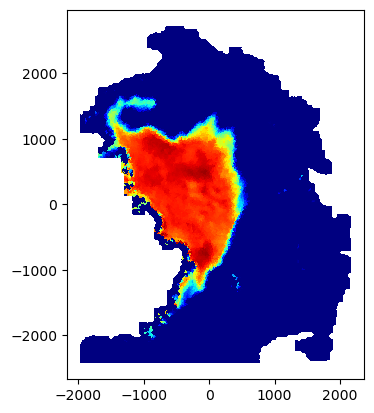

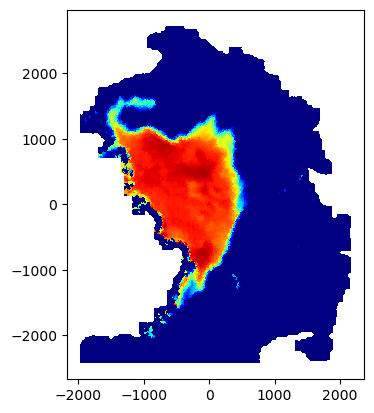

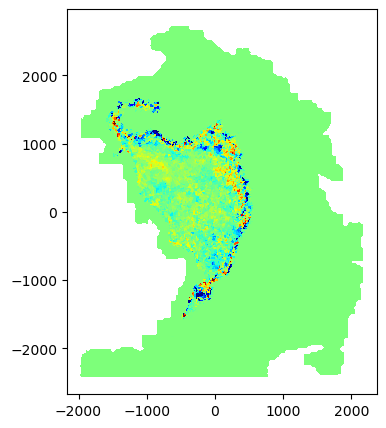

In [87]:
plt.tripcolor(x1_mesh, y1_mesh, t1, dst_saved_data[myi_name_DA], vmin=0, vmax=100, cmap='jet')
plt.gca().set_aspect('equal')
plt.show()

plt.tripcolor(x1_mesh, y1_mesh, t1, dst_myi[myi_name_DA], vmin=0, vmax=100, cmap='jet')
plt.gca().set_aspect('equal')

plt.show()
overestimation = dst_myi[myi_name_DA] - dst_saved_data[myi_name_DA]

plt.figure(figsize=(5,5))
plt.tripcolor(x1_mesh, y1_mesh, t1, overestimation, vmin=-5, vmax=5, cmap='jet')
plt.gca().set_aspect('equal')
plt.show()

